# Laboratorio 7

### Integrantes
Joaquin Campos 22155   
Francis Aguilar 22243

Repositorio: https://github.com/JoaquinCampos22155/lab7-DL 

## Task 1

In [27]:
# %pip install --upgrade pip
# %pip install "gymnasium[classic-control]" numpy matplotlib

In [28]:
# Imports, dispositivo y semillas
import math
import random
from collections import deque, namedtuple
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


Device: cpu


In [21]:
# Crear el entorno CartPole 
RENDER = True

def make_env(render: bool, seed: int = SEED):
    render_mode = "human" if render else None
    env = gym.make("CartPole-v1", render_mode=render_mode)
    obs, info = env.reset(seed=seed)
    return env, obs, info

env, obs, info = make_env(RENDER, seed=SEED)
n_obs = env.observation_space.shape[0]   
n_act = env.action_space.n               
n_obs, n_act


(4, np.int64(2))

In [30]:
# Redes en línea y de destino
class QNet(nn.Module):
    def __init__(self, n_obs, n_act, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(n_obs, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, n_act)
        # Inicializaciones útiles
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity="relu")
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity="relu")
        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

policy_net = QNet(n_obs, n_act).to(device)  
target_net = QNet(n_obs, n_act).to(device)  
target_net.load_state_dict(policy_net.state_dict())  
target_net.eval()  


QNet(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
)

In [31]:
# Hiperparámetros
EPISODES = 600
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3

# Exploración ε-greedy
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 50_000  # pasos para decaer de 1.0 a 0.05

# Replay buffer
REPLAY_CAPACITY = 50_000
TRAIN_START = 1_000  # mínimo de transiciones antes de entrenar

# Actualización de la red objetivo
TARGET_UPDATE_EPISODES = 10

# Seguridad / utilidades
GRAD_CLIP = 10.0
MAX_STEPS = 300_000  # tope duro por seguridad


In [ ]:
# Selección de acciones ε-greedy
global_step = 0  

def epsilon_by_step(step: int) -> float:
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + (EPS_END - EPS_START) * frac

@torch.no_grad()
def select_action(state, eps: float) -> int:
    if random.random() < eps:
        return env.action_space.sample()
    s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    q_vals = policy_net(s)
    return int(torch.argmax(q_vals, dim=1).item())


In [33]:
# Experience Replay
Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "done"))

class ReplayBuffer:
    def __init__(self, capacity=REPLAY_CAPACITY):
        self.buf = deque(maxlen=capacity)
    def push(self, *args):
        self.buf.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        return Transition(*zip(*batch))
    def __len__(self):
        return len(self.buf)

memory = ReplayBuffer(REPLAY_CAPACITY)


In [34]:
# Optimizador y actualización de parámetros
optimizer = optim.Adam(policy_net.parameters(), lr=LR)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return None

    batch = memory.sample(BATCH_SIZE)

    state_b = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
    action_b = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
    reward_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
    next_state_b = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
    done_b = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

    # Q(s,a) actual
    q_values = policy_net(state_b).gather(1, action_b)

    # Objetivo DQN estándar con red objetivo: y = r + gamma * max_a' Q_target(s', a') si no terminal
    with torch.no_grad():
        next_q_values = target_net(next_state_b).max(1, keepdim=True)[0]
        target = reward_b + (1.0 - done_b) * GAMMA * next_q_values

    loss = F.smooth_l1_loss(q_values, target)  # Huber loss

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item())


In [41]:
def train_agent(env, policy_net, target_net, optimizer, memory, episodes=EPISODES, render=False):
   
    global global_step
    episode_rewards = []
    losses = []

    for ep in range(episodes):
        state, info = env.reset(seed=SEED)
        ep_reward = 0

        for t in range(1, 10000):  
            eps = epsilon_by_step(global_step)
            action = select_action(state, eps)
            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated
            memory.push(state, action, reward, next_state, done)
            state = next_state
            ep_reward += reward
            global_step += 1

            if render:
                env.render()

            # Optimización
            loss = optimize_model()
            if loss is not None:
                losses.append(loss)

            if done:
                break

        episode_rewards.append(ep_reward)

        # Actualizar red objetivo cada N episodios
        if ep % TARGET_UPDATE_EPISODES == 0:
            target_net.load_state_dict(policy_net.state_dict())

        print(f"Ep {ep+1}/{episodes} | Recompensa: {ep_reward:.1f} | Eps: {eps:.3f}")

    # Cerrar el entorno al final
    env.close()

    return episode_rewards, losses

In [42]:
# Gráfica de recompensas
def graficar(episode_rewards):
    plt.figure(figsize=(10,5))
    plt.plot(episode_rewards, label="Recompensa por episodio")
    plt.xlabel("Episodios")
    plt.ylabel("Recompensa total")
    plt.title("Progreso del entrenamiento en CartPole-v1")
    plt.legend()
    plt.show()


Ep 1/600 | Recompensa: 41.0 | Eps: 0.992
Ep 2/600 | Recompensa: 22.0 | Eps: 0.991
Ep 3/600 | Recompensa: 20.0 | Eps: 0.991
Ep 4/600 | Recompensa: 10.0 | Eps: 0.991
Ep 5/600 | Recompensa: 15.0 | Eps: 0.990
Ep 6/600 | Recompensa: 11.0 | Eps: 0.990
Ep 7/600 | Recompensa: 35.0 | Eps: 0.989
Ep 8/600 | Recompensa: 9.0 | Eps: 0.989
Ep 9/600 | Recompensa: 31.0 | Eps: 0.989
Ep 10/600 | Recompensa: 11.0 | Eps: 0.989
Ep 11/600 | Recompensa: 10.0 | Eps: 0.988
Ep 12/600 | Recompensa: 28.0 | Eps: 0.988
Ep 13/600 | Recompensa: 27.0 | Eps: 0.987
Ep 14/600 | Recompensa: 27.0 | Eps: 0.987
Ep 15/600 | Recompensa: 40.0 | Eps: 0.986
Ep 16/600 | Recompensa: 30.0 | Eps: 0.985
Ep 17/600 | Recompensa: 22.0 | Eps: 0.985
Ep 18/600 | Recompensa: 11.0 | Eps: 0.985
Ep 19/600 | Recompensa: 17.0 | Eps: 0.984
Ep 20/600 | Recompensa: 14.0 | Eps: 0.984
Ep 21/600 | Recompensa: 28.0 | Eps: 0.984
Ep 22/600 | Recompensa: 36.0 | Eps: 0.983
Ep 23/600 | Recompensa: 13.0 | Eps: 0.983
Ep 24/600 | Recompensa: 10.0 | Eps: 0.983
Ep

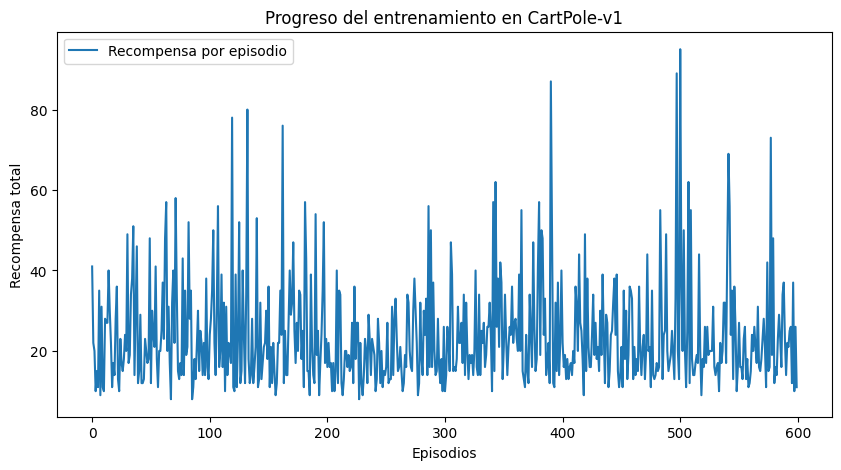

In [43]:
# Entrenar al agente
episode_rewards, losses = train_agent(env, policy_net, target_net, optimizer, memory, episodes=EPISODES, render=RENDER)

# Graficar las recompensas
graficar(episode_rewards)

In [44]:
def evaluate_agent(env, n_eval_episodes=10):
    rewards = []
    for ep in range(n_eval_episodes):
        state, info = env.reset(seed=SEED)
        ep_reward = 0
        done = False
        while not done:
            action = select_action(state, eps=0.0)  # sin exploración
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = next_state
            ep_reward += reward
        rewards.append(ep_reward)
    return rewards

# Crear un entorno sin render para la evaluación
eval_env, _, _ = make_env(render=False, seed=SEED)
eval_rewards = evaluate_agent(eval_env)
eval_env.close()

print("Recompensa promedio:", np.mean(eval_rewards))


Recompensa promedio: 61.0


- **Gamma (γ):** probar 0.98–0.995.
- **Exploración (ε):** ajustar `EPS_DECAY_STEPS` (30k–70k pasos) y `EPS_END` (0.01–0.1).
- **Batch size:** 64–128.
- **LR:** si hay oscilaciones, bajar a `5e-4` o `1e-4`.
- **Arquitectura:** capas [128,128] → [256,256] si el aprendizaje es lento.
- **Replay warmup:** aumentar `TRAIN_START` a 5k si hay inestabilidad.
- **Target Update:** probar `TARGET_UPDATE_EPISODES` en 5–20.
- **Double DQN:** reduce sobreestimación (ver bloque opcional).
- **Soft Update (Polyak):** alternativa al update por episodios (ver bloque opcional).


#### Fine tuning


In [45]:
# Hiperparámetros
EPISODES = 600
GAMMA = 0.99
BATCH_SIZE = 128 # aumentamos el batch size
LR = 2.5e-4 # ajustamos 

# Exploración ε-greedy
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 100_000  # aumentamos los pasos

# Replay buffer
REPLAY_CAPACITY = 100_000 # aumentamos la capacidad
TRAIN_START = 1_000  # mínimo de transiciones antes de entrenar

# Actualización de la red objetivo
TARGET_UPDATE_EPISODES = 10

# Seguridad / utilidades
GRAD_CLIP = 10.0
MAX_STEPS = 300_000  # tope duro por seguridad

# cambiamos adam por RMSprop
optimizer = optim.RMSprop(policy_net.parameters(), lr=LR)



Ep 1/600 | Recompensa: 11.0 | Eps: 0.860
Ep 2/600 | Recompensa: 19.0 | Eps: 0.860
Ep 3/600 | Recompensa: 20.0 | Eps: 0.860
Ep 4/600 | Recompensa: 27.0 | Eps: 0.860
Ep 5/600 | Recompensa: 31.0 | Eps: 0.860
Ep 6/600 | Recompensa: 11.0 | Eps: 0.859
Ep 7/600 | Recompensa: 23.0 | Eps: 0.859
Ep 8/600 | Recompensa: 49.0 | Eps: 0.859
Ep 9/600 | Recompensa: 17.0 | Eps: 0.859
Ep 10/600 | Recompensa: 16.0 | Eps: 0.858
Ep 11/600 | Recompensa: 12.0 | Eps: 0.858
Ep 12/600 | Recompensa: 11.0 | Eps: 0.858
Ep 13/600 | Recompensa: 28.0 | Eps: 0.858
Ep 14/600 | Recompensa: 26.0 | Eps: 0.858
Ep 15/600 | Recompensa: 16.0 | Eps: 0.858
Ep 16/600 | Recompensa: 10.0 | Eps: 0.857
Ep 17/600 | Recompensa: 11.0 | Eps: 0.857
Ep 18/600 | Recompensa: 19.0 | Eps: 0.857
Ep 19/600 | Recompensa: 17.0 | Eps: 0.857
Ep 20/600 | Recompensa: 70.0 | Eps: 0.856
Ep 21/600 | Recompensa: 45.0 | Eps: 0.856
Ep 22/600 | Recompensa: 22.0 | Eps: 0.856
Ep 23/600 | Recompensa: 17.0 | Eps: 0.856
Ep 24/600 | Recompensa: 22.0 | Eps: 0.855
E

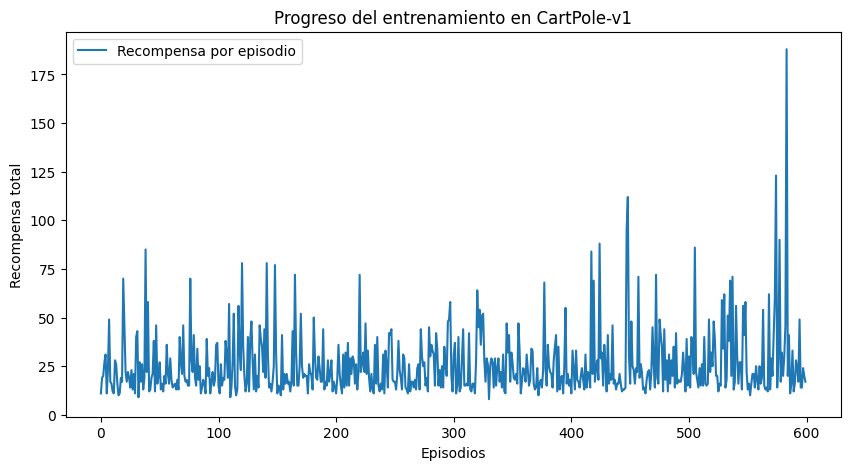

In [46]:
# Entrenar al agente
episode_rewards, losses = train_agent(env, policy_net, target_net, optimizer, memory, episodes=EPISODES, render=RENDER)

# Graficar las recompensas
graficar(episode_rewards)

In [47]:
# Crear un entorno sin render para la evaluación
eval_env, _, _ = make_env(render=False, seed=SEED)
eval_rewards = evaluate_agent(eval_env)
eval_env.close()

print("Recompensa promedio:", np.mean(eval_rewards))


Recompensa promedio: 90.0


# Task 2

# Proximal Policy Optimization (PPO)

## Qué es:
Una forma de enseñar a un “agente” a mejorar poco a poco sin dar pasos bruscos. Es como aprender a andar en patines: se avanza, se prueba algo nuevo, pero con barandal al lado para no caerse.

## Cuándo usarlo:
- Cuando se busca obtener resultados estables y confiables sin entrar en demasiadas complicaciones.  
- Funciona bien tanto si las decisiones son “botón A/B/C” como si son “mover el volante un poco”.  
- Útil en videojuegos, robots sencillos o simulaciones donde se prefiere robustez antes que exprimir cada dato al máximo.  

---

# Deep Deterministic Policy Gradients (DDPG)

## Qué es:
Un estilo de aprendizaje que prefiere “perillas” continuas en vez de botones. Es como ajustar el volumen con una perilla: el agente aprende a ponerla en el punto justo. Además, se aprovechan experiencias pasadas para aprender más con menos intentos.

## Cuándo usarlo:
- Cuando las acciones no son discretas (por ejemplo, girar un brazo robótico ciertos grados o dosificar una válvula).  
- Cuando probar cosas es costoso o lento y se necesita aprovechar al máximo cada práctica.  
- Ideal para control fino y ajustes precisos.  

---

# Trust Region Policy Optimization (TRPO)

## Qué es:
Un método que se asegura de que cada paso de aprendizaje no cambie demasiado lo que el agente hace. Es como mejorar una receta sin alterar el plato por completo: pequeños cambios con control para no arruinar lo que ya funciona.

## Cuándo usarlo:
- Cuando la estabilidad es prioridad (por ejemplo, coordinación de movimientos en robots).  
- Cuando se buscan actualizaciones conservadoras que eviten “dar volantazos” en el comportamiento.  
- Útil en tareas complejas donde un cambio grande podría echar a perder el progreso.  

---

# Asynchronous Advantage Actor–Critic (A3C)

## Qué es:
Se ponen muchos aprendices a practicar en paralelo, cada uno probando cosas distintas, y luego se junta lo aprendido. Como un equipo que entrena en canchas diferentes y comparte sus mejores trucos.

## Cuándo usarlo:
- Cuando se dispone de varios núcleos de CPU y se quiere acelerar el aprendizaje corriendo muchas simulaciones a la vez.  
- Bueno para juegos y entornos variados donde la diversidad de experiencias ayuda a explorar más rápido.  
- Útil si se busca evitar almacenar grandes historiales y confiar en la variedad que dan muchos aprendices simultáneos.  

---

# Referencias 

Lillicrap(2016). Continuous control with deep reinforcement learning. https://arxiv.org/abs/1509.02971
 

Mnih, V., Badia(2016). Asynchronous methods for deep reinforcement learning.https://proceedings.mlr.press/v48/mniha16.pdf
 
Schulman, J., Wolski(2017). Proximal policy optimization algorithms. https://arxiv.org/abs/1707.06347
 